# <span style="color:red; font-size: 30px"> Assignment 8 - Due Tuesday, April 7th at 8am ET</span>

<font size = "3">

This is a graded homework assignment - no part may be used within a prompt to an LLM

Complete the code cells in this Jupyter notebook, and submit the final .ipynb notebook to Gradescope.

**Please do the following in VS code before you submit**:

- Click "Clear All Outputs"

- Click "Restart"

- Run all code cells

- Save the file

**Note:** Output should match the code that appears in its corresponding cell.

<font size = "4">

Import the familiar libraries ``pandas``, ``numpy`` and ``matplotlib.pyplot``

In addition, we'll import a sublibrary from the ``statsmodels`` library. We'll use this in problems 4 and 5

In [9]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

# for problems (d) and (e)
import statsmodels.formula.api as smf

<font size = "5">

(a) Cleaning data

<font size = "4">

Run the code cell below to create a DataFrame filled with synthetic (i.e. fake) data. The column "reported_value" should consist of numerical values, but some of the entries need to be cleaned for the following reasons:

- Some of the values contain extra characters (like commas or parentheses)

- Some of the values include units written as letters

Clean the data, overwriting the "reported_value" column so that it contains all numeric values.

You should use the following methods/functions in your solution:

- `.str.is_numeric`

- `pd.unique` (or you can use the `.unique` method)

- `.replace` 

- `pd.to_numeric`

- You may use any other methods that are necessary or convenient for the problem.

After cleaning the data, print/display the changed DataFrame to the screen. (Don't create a brand-new DataFrame.)

<br>

<font size = "2">

**Note:** Just using `pd.to_numeric` with `errors = "coerce"` would give you the wrong answer.

In [10]:
import pandas as pd 
id_list = ["S001", "S002", "S003", "S004", "S005", "S006", 
        "S007", "S008", "S009", "S010", "S011", "S012"]

grp_list = ["control", "control", "treatment", "control",
        "treatment", "treatment", "control", "control",
        "treatment", "control", "treatment", "control"]

val_list = ["42", "1,250", "37", "~60", "18", "(25)",
    "42", "40 mg", "18", "1,250", "~60", "(25)"]

date_list = [ "2025-01-12", "2025-01-12", "2025-01-13", "2025-01-13",
        "2025-01-14", "2025-01-14", "2025-01-15", "2025-01-15",
        "2025-01-16", "2025-01-16","2025-01-17", "2025-01-17"]

data_dict = {"subject_id" : id_list, "group" : grp_list, 
    "reported_value": val_list, "measurement_date": date_list}

df = pd.DataFrame(data_dict)


In [11]:
# add your code performing the cleaning process here
df_non_number = df.query("reported_value.str.isnumeric() == False")
non_numbers = pd.unique(df_non_number["reported_value"])
print(non_numbers)
replacement = [1250, 60, 25, 40]
df["reported_value"] = df["reported_value"].replace(non_numbers, replacement)
df["reported_value"] = pd.to_numeric(df["reported_value"])
print(df)



['1,250' '~60' '(25)' '40 mg']
   subject_id      group  reported_value measurement_date
0        S001    control              42       2025-01-12
1        S002    control            1250       2025-01-12
2        S003  treatment              37       2025-01-13
3        S004    control              60       2025-01-13
4        S005  treatment              18       2025-01-14
5        S006  treatment              25       2025-01-14
6        S007    control              42       2025-01-15
7        S008    control              40       2025-01-15
8        S009  treatment              18       2025-01-16
9        S010    control            1250       2025-01-16
10       S011  treatment              60       2025-01-17
11       S012    control              25       2025-01-17


<font size = "5">

(b) Replace the values of a column

<font size = "4">

- Consider the DataFrame ``df_movies`` created below.
- In the "country" column, change the values "American" and "Korean" to "USA" and "ROK" respectively
- Do this by using the ``.replace`` method.

In [12]:
# Create example DataFrame - **don't change this cell**
titles = ["Past Lives", "Citizen Kane", "Revenge", "Okja", "Shutter", 
    "A Tale of Two Sisters", "La Chinoise", "The Umbrellas of Cherbourg", "House",
    "Suspiria", "Blue Velvet"]
country = ["American", "American", "France", "Korean", "Thailand", "Korean", "France",
    "France", "Japan", "Italy", "American"]
runtime = [106, 119, 108, 120, 97, 115, 96, 91, 88, 98, 120]
year = [2023, 1941, 2017, 2017, 2004, 2003, 1967, 1964, 1977, 1977, 1986]
movie_dict = {"title" : titles, "country" : country, "runtime" : runtime, "year" : year}
df_movies = pd.DataFrame(movie_dict)

In [13]:
# Write your answer here
origin = ["American", "Korean"]
replacement=["USA", "ROK"]
df_movies["country"] = df_movies["country"].replace(origin, replacement)
print(df_movies)



                         title   country  runtime  year
0                   Past Lives       USA      106  2023
1                 Citizen Kane       USA      119  1941
2                      Revenge    France      108  2017
3                         Okja       ROK      120  2017
4                      Shutter  Thailand       97  2004
5        A Tale of Two Sisters       ROK      115  2003
6                  La Chinoise    France       96  1967
7   The Umbrellas of Cherbourg    France       91  1964
8                        House     Japan       88  1977
9                     Suspiria     Italy       98  1977
10                 Blue Velvet       USA      120  1986


<font size = "5">

(c) Merge dataset

<font size = "4">

- Consider the DataFrames ``df_movies`` (created above) and ``df_scores`` (created below)

- Create a new dataset using  ```pd.merge()``` using
"df_movies" as the primary dataset, and
"df_scores" as the secondary dataset, merging on
the column "title"

- You should **ONLY** merge the "imdb_score" column <br>
from the secondary dataset (not the "director" column)

HINT: Use ```[[...]]``` to extract a subset of columns <br>
from the secondary dataset before merging

In [14]:
# create example DataFrame - don't change this cell
titles = ["Past Lives", "Citizen Kane", "Revenge", "Okja", "Shutter", 
    "A Tale of Two Sisters", "La Chinoise", "The Umbrellas of Cherbourg", "House",
    "Suspiria", "Blue Velvet"]
scores = [7.8, 8.2, 6.4, 7.3, 7.0, 7.1, 6.9, 7.8, 7.2, 7.3, 7.7]
directors = ["Celine Song", "Orson Welles", "Coralie Fargeat", "Bong Joon Ho", 
    "Banjong Pisanthanakun", "Kim Jee-woon", "Jean-Luc Godard", "Jacques Demy", 
    "Nobuhiko Obayashi", "Dario Argento", "David Lynch"]

movie_dict2 = {"title" : titles, "imdb_score" : scores, "director" : directors}
df_scores = pd.DataFrame(movie_dict2)

In [15]:
# Write your answer here
df_merged = pd.merge(left=df_movies, right=df_scores[["title", "imdb_score"]], how= "left", on= "title")
print(df_merged)


                         title   country  runtime  year  imdb_score
0                   Past Lives       USA      106  2023         7.8
1                 Citizen Kane       USA      119  1941         8.2
2                      Revenge    France      108  2017         6.4
3                         Okja       ROK      120  2017         7.3
4                      Shutter  Thailand       97  2004         7.0
5        A Tale of Two Sisters       ROK      115  2003         7.1
6                  La Chinoise    France       96  1967         6.9
7   The Umbrellas of Cherbourg    France       91  1964         7.8
8                        House     Japan       88  1977         7.2
9                     Suspiria     Italy       98  1977         7.3
10                 Blue Velvet       USA      120  1986         7.7


<font size = "5">

(d) Linear Regression

<font size = "4">

We return to the dataset of car features, in the file `features.csv`. We might guess that there is a simple linear relationship between the weight of a car and its miles per gallon (the heavier the car, the worse mileage it gets).

In particular, we expect that these two variables are related by the approximate equality:

$$ m_i \approx a\cdot w_i + b$$

where $m_i$ is the mpg of car $i$, $w_i$ is the weight of car $i$, and $a$ (the slope) and $b$ (the y-intercept) are the coefficients of the linear model - which we need to determine. In this model, we say that "weight" is the **independent variable** and "mpg" is the **dependent variable**


- Read in the carfeatures dataset, and assign it to a DataFrame.

- At the top of the notebook, we imported the library ``statsmodels.formula.api`` with the nickname ``smf``. To construct the model, we will use the ``smf.ols`` (Ordinary Least Squares) function as follows:
```python
        model = smf.ols(formula = ... , data = ...)
```
- Replace the ellipses (...) in the arguments as follows:
    - For formula, you should put the **string** "dependent_variable ~ independent_variable", where you should substitute the appropriate DataFrame column names for the two variables. (But keep the tilde (~) there)
    - The data argument corresponds to the DataFrame you created when you read in the .csv file.

- Compute a Pandas ``Series`` containing the computed coefficients $a$ and $b$ from the linear model. You can do this as follows:
```python
        coeffs = model.fit().params
```

This problem is continued in Question (5)

In [16]:
# your answer here
df_features = pd.read_csv("data/features.csv")
model = smf.ols(formula = "mpg~weight ", data = df_features)
coeffs = model.fit().params



<font size = "5">

(e) Plotting Linear Regression Model

<font size = "4">

In Question (d), you created a Pandas ``Series`` containing the coefficients of the linear model

$$ m_i \approx a\cdot w_i + b$$

- The elements of ``coeffs`` can be accessed as ``coeffs["Intercept"]`` (the y-intercept) and ``coeffs["weight"]`` (the slope). Define two separate floating-point number variables ``a`` and ``b`` corresponding to the model above.

- Create a Pandas ``Series`` called ``predicted_mpg`` based on the formula:
$$\hat{m}_i = a\cdot w_i + b$$

- This means that each element of ``predicted_mpg`` is computed by multiplying ``a`` by the corresponding element in the "weight" column, and then adding ``b``. **Hint:** It's just like if you were working with Numpy arrays.

- Using ``plt.scatter`` plot weight (on the x-axis) against mpg (on the y-axis). 

- Then using ``plt.plot`` (**not a scatter plot!**) plot weight (on the x-axis) against ``predicted_mpg`` (on the y-axis). They should appear on the same figure as long as you don't type ``plt.show`` in between. 

- Change the color of either the scatter plot or regular plot, so that they are easily distinguished from each other.

- Label the axes, add a legend, and a title to your plot. For the legend, you might want to call the points in the scatter plot "data", and the linear fit line "best fit line".

- Make sure your plots are output to the screen before submitting

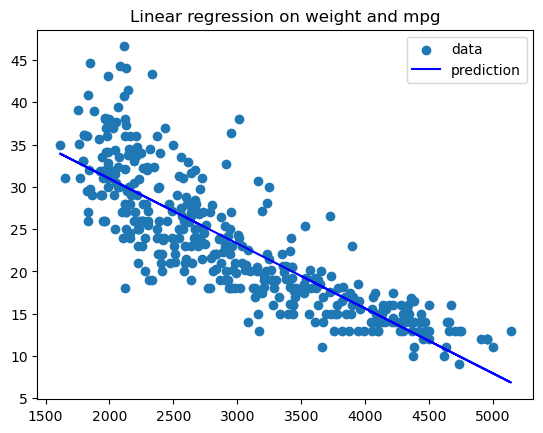

In [19]:
# your answer here
a = coeffs["weight"]
b = coeffs["Intercept"]
predicted_mpg = a * df_features["weight"] + b
plt.scatter(df_features["weight"], df_features["mpg"], label = "data")
plt.plot(df_features["weight"], predicted_mpg, color = "blue", label = "prediction")
plt.legend()
plt.title("Linear regression on weight and mpg")
plt.show()


